# Function 8: High-dimensional Optimisation
You’ve reach the final, 8-dimensional search space. High-dimensional black-box optimisation can be very difficult, so sticking to local solutions is not the worst idea here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.decomposition import PCA

In [2]:
def load_inputs(file_path):
    with open(file_path, "r") as f:
        content = f.read()

    # Make the file a proper list of lists
    content = "[" + content.replace("]\n[", "],[") + "]"

    # Safe eval with restricted globals
    return eval(content, {"array": np.array})


def load_outputs(file_path):
    with open(file_path, "r") as f:
        content = f.read()

    content = "[" + content.replace("]\n[", "],[") + "]"

    return eval(content, {"np": np})


def get_input_points(function_number, file_path="../inputs.txt"):
    if not 1 <= function_number <= 8:
        raise ValueError("Function number must be between 1 and 8")

    data = load_inputs(file_path)
    index = function_number - 1

    inputs = [dataset[index] for dataset in data]
    return np.array(inputs)


def get_output_points(function_number, file_path="../outputs.txt"):
    if not 1 <= function_number <= 8:
        raise ValueError("Function number must be between 1 and 8")

    data = load_outputs(file_path)
    index = function_number - 1

    outputs = [row[index] for row in data]
    return np.array(outputs)

# Load inputs
X = np.load(r'initial_inputs.npy')
y = np.load(r'initial_outputs.npy')


# Get input and outputs from submissions
inputs_array = get_input_points(8)
outputs_array = get_output_points(8)


# Append inputs_f1_array to X
X = np.vstack((X, inputs_array))

# Append outputs_f1_array to Y
y = np.hstack((y, outputs_array))

print("New shape of X:", X.shape)
print("New shape of Y:", y.shape)

New shape of X: (47, 8)
New shape of Y: (47,)


In [3]:
def generate_nd_grid(max_points, dimensions):
    # define range for input
	r_min, r_max = 0, 1.0

	# generate a random sample from the domain (dimensions)
	nd_grid = r_min + np.random.rand(max_points, dimensions) * (r_max - r_min)

	return np.array(nd_grid)

In [4]:
max_points = 800000
dimensions = 8  # Change this to the desired number of dimensions
X_grid = []
X_grid = generate_nd_grid(max_points, dimensions)
X_grid

array([[0.51611847, 0.23346803, 0.86670537, ..., 0.09028434, 0.76515995,
        0.88862625],
       [0.20270502, 0.29978115, 0.93628318, ..., 0.51114812, 0.66959406,
        0.933611  ],
       [0.87759083, 0.61958027, 0.29317014, ..., 0.36705452, 0.04593468,
        0.38831254],
       ...,
       [0.02286227, 0.83866365, 0.59920857, ..., 0.76908824, 0.06498129,
        0.55599796],
       [0.94279697, 0.29919248, 0.55862454, ..., 0.59946164, 0.42093023,
        0.29046311],
       [0.76282716, 0.06818476, 0.23691025, ..., 0.17810247, 0.62185055,
        0.95814677]])

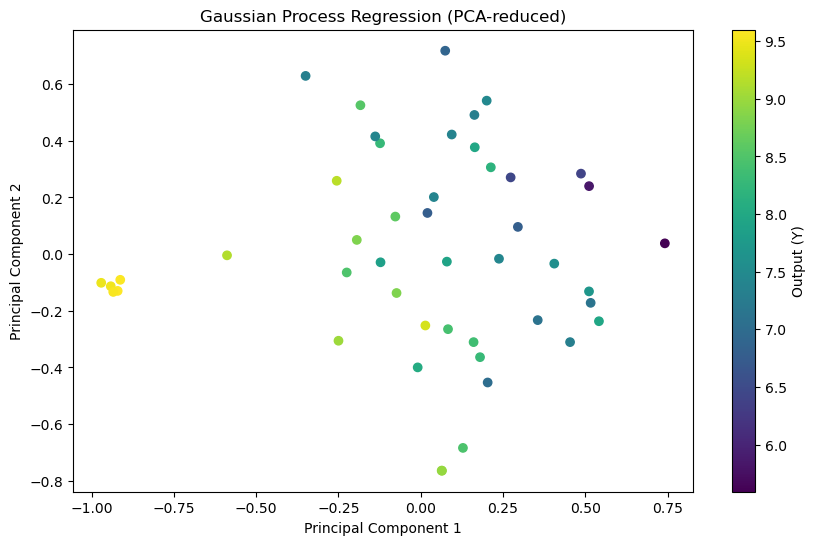

Next point to evaluate (unscaled): 0.104413-0.269572-0.134906-0.077132-0.560759-0.554869-0.268679-0.433520


In [5]:


# Create a GPR model (no change here)
kernel = RBF(length_scale=1.0)  # You may need to adjust kernel and length scale
gpr = GaussianProcessRegressor(kernel=kernel)

# Correctly fit the GPR model with all 8 dimensions
gpr.fit(X, y)

#For visualization, we'll use PCA to reduce to 2 dimensions for plotting

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot the results in 2D
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis')  #Color points by Y value
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Gaussian Process Regression (PCA-reduced)')
plt.colorbar(label='Output (Y)')
plt.show()

def upper_confidence_bound(X_grid, gpr, beta):
    """
    Computes the Upper Confidence Bound (UCB) acquisition function for maximization.

    Args:
        X: Input points (array-like).
        gpr: Trained Gaussian Process Regressor.
        beta: Exploration-exploitation parameter (higher beta means more exploration).

    Returns:
        UCB value for each input point (array-like).
    """
    mu, sigma = gpr.predict(X_grid, return_std=True)
    return mu + beta * sigma

# Example usage (assuming 'gpr' is your trained GPR model):

# Calculate UCB for these points (adjust beta as needed)
beta = 2.0  # exploration-exploitation tradeoff
ucb_values = upper_confidence_bound(X_grid, gpr, beta)

# Find the point with the highest UCB (most promising)
next_point = X_grid[np.argmax(ucb_values)]

formatted_next_query = f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}-{next_point[3]:.6f}-{next_point[4]:.6f}-{next_point[5]:.6f}-{next_point[6]:.6f}-{next_point[7]:.6f}"
print("Next point to evaluate (unscaled):", formatted_next_query)